# Lecture 3  : Lab - Feature Extraction With Python

- Library:  For Feature Extraction  --> skimage
- Database : Cifar10

### here we are using Python version  - 2.7 

In [2]:
# pip install torchvision

In [3]:
pip install --ignore-installed numpy scikit-image

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\sangr\\anaconda3\\Lib\\site-packages\\numpy\\linalg\\_umath_linalg.cp39-win_amd64.pyd'
Consider using the `--user` option or check the permissions.




  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
  Using cached scikit_image-0.24.0-cp39-cp39-win_amd64.whl.metadata (14 kB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl.metadata (60 kB)
  Using cached networkx-3.2.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached pillow-11.3.0-cp39-cp39-win_amd64.whl.metadata (9.2 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2024.8.30-py3-none-any.whl.metadata (31 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
Using cached scikit_image-0.24.0-cp39-cp39-win_amd64.whl (12.9 MB)
Using cached imageio-2.37.2-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
Using cached networkx-3.2.1-py3-none-any.whl (1.6 MB)
Using cached packaging-26.0-py3-none-any.whl (74 kB)
Using cached pillow-11.3.0-cp39-cp39-win_amd6

In [4]:
# pip install "numpy<2.0"

In [5]:
%matplotlib inline

from torchvision import datasets   # importing Dataset from Library PyTorch With Specific from torchvision
import PIL     # Python Image Library --> reading and writing down the Image
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
# we importing some python files to our esource path 
from skimage.filters import gabor  #to call gabor filter
import numpy as np       # Numerical Programming Lib for defining arrays and D.Structure of array
import pickle    # use for Storing Data
import matplotlib.pyplot as plt   # for Ploting Graphs

# Downloading Dataset


- CIFAR10   : Small Image dataset  (32 x32)

In [6]:
trainset = datasets.CIFAR10('./cifar10/',train = True , download = True)
testset = datasets.CIFAR10('./cifar10/' , train= False, download = True)

###  Size of Train and Test Dataset

In [7]:
print('no of sample in train Set : '+str(len(trainset)))
print(' no of sample in test set: '+str(len(testset)))

no of sample in train Set : 50000
 no of sample in test set: 10000


### Feature Extraction  on singlr image

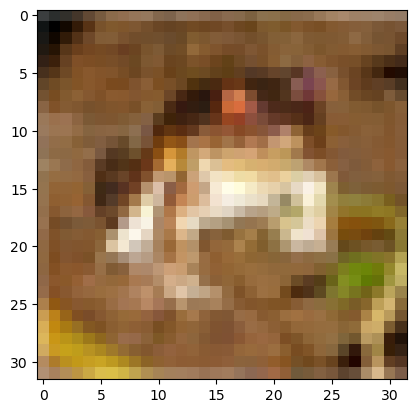

In [8]:
img = trainset[0][0]   # PIL image
img_gray = img.convert('L')  # converting image to grayscale
img_arr = np.array(img_gray)  # Convering to array
plt.imshow(img)


# ☺ this is imag. of 🐸 frog 

# LBP


## Finding LBP

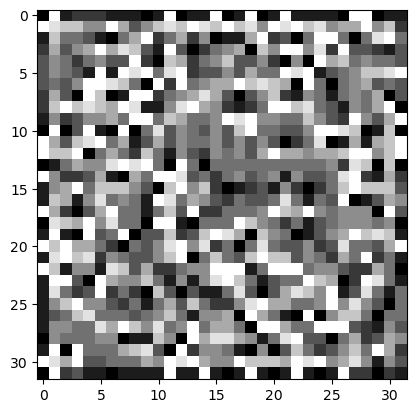

In [9]:
feat_lbp  =  local_binary_pattern(img_arr, 8,1, 'uniform')   ##Radius = 1, No. of neighbours = 8   Taking circular Pattern
feat_lbp  = np.uint8((feat_lbp/feat_lbp.max())*255)  # Converting to unit8
lbp_img  = PIL.Image.fromarray(feat_lbp)  # Converting from array to PIL Image
plt.imshow(lbp_img, cmap='gray')   # Display LBP

In [10]:
# Energy and Entropy 

lbp_hist,_  = np.histogram(feat_lbp, 8)            # Histogram Computed
lbp_hist = np.array(lbp_hist, dtype=float)
lbp_prob = np.divide(lbp_hist, np.sum(lbp_hist))    # Getting probability PDF
lbp_energy = np.sum(lbp_prob**2)                     
lbp_entropy  = -np.sum(np.multiply(lbp_prob, np.log2(lbp_prob)))

print('LBP energy = '+str(lbp_energy))
print('LBP entropy = '+str(lbp_entropy))

LBP energy = 0.14315032958984375
LBP entropy = 2.8972505530220363


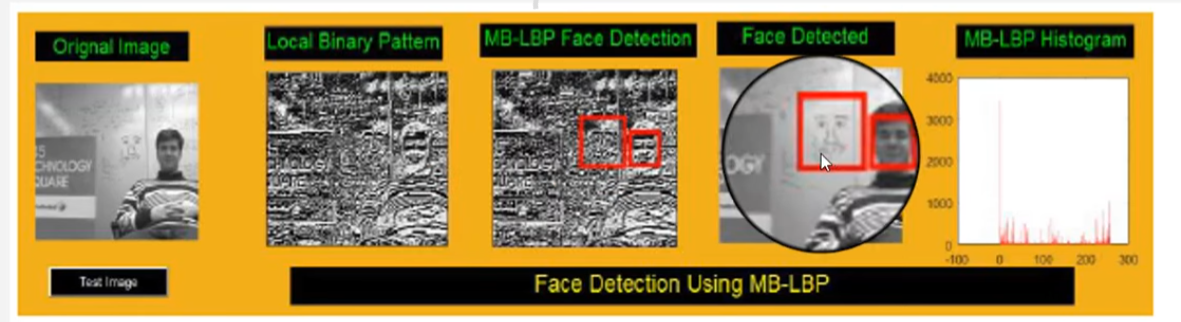
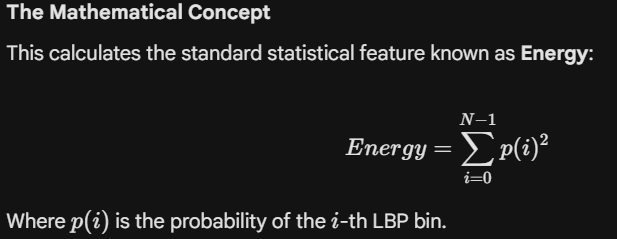

 #  Co-occurance Matrix  


 ### Finding GLCM features from co-occurance matrix

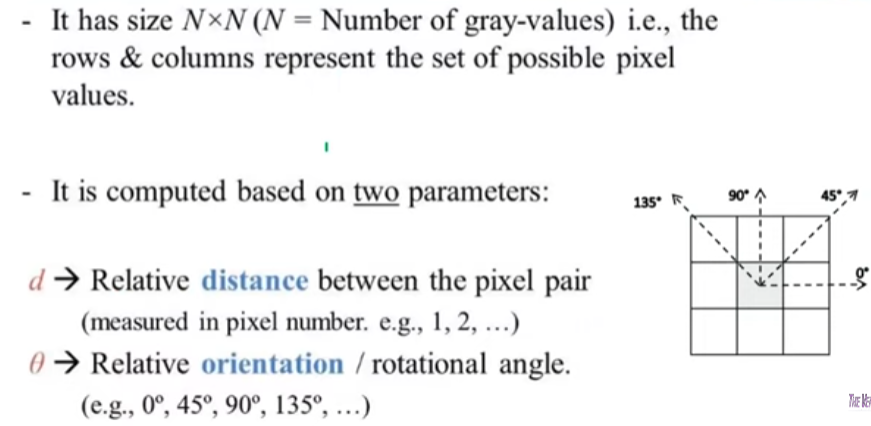

In [11]:

# gCoMat  ==> Gray level Co-occurance Matrix

gCoMat = graycomatrix(img_arr, [2], [0], 256, symmetric = True, normed = True)  # Co-occurance Matrix

# here we can't take 256 gray levels , so we taking only specific as follows

# Scaler Values
contrast = graycoprops(gCoMat, prop = 'contrast')
dissimilarity = graycoprops (gCoMat, prop = 'dissimilarity')
homogeneity = graycoprops(gCoMat, prop = 'homogeneity')
energy = graycoprops(gCoMat, prop = 'energy')
correlation = graycoprops(gCoMat, prop = 'correlation')

print('Contrast = '+str(contrast[0][0]))
print('Dissimilarity = '+str(dissimilarity[0][0]))
print('Homogeneity = '+str(homogeneity[0][0]))
print('Energy = '+str(energy[0][0]))
print('Correlation = '+str(correlation[0][0]))

Contrast = 1296.8916666666667
Dissimilarity = 24.225
Homogeneity = 0.06323755700795275
Energy = 0.027282918445226657
Correlation = 0.6119618429581918


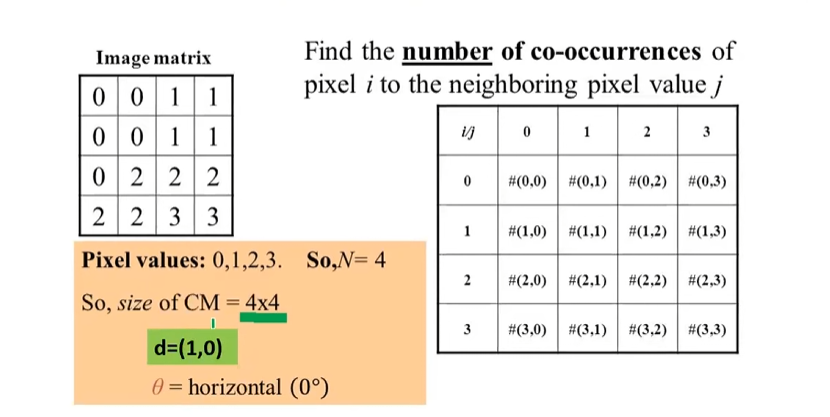


https://www.youtube.com/watch?v=oPttO98Y6yg

# Gabor Filter

https://www.youtube.com/watch?v=yn1NUwaxhZg

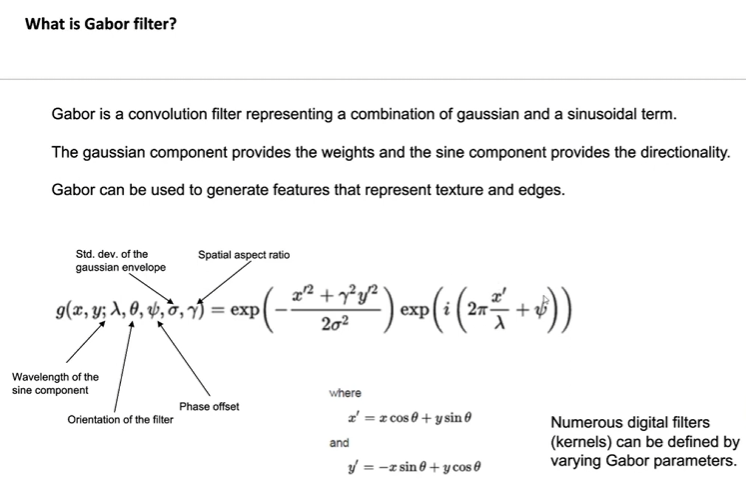

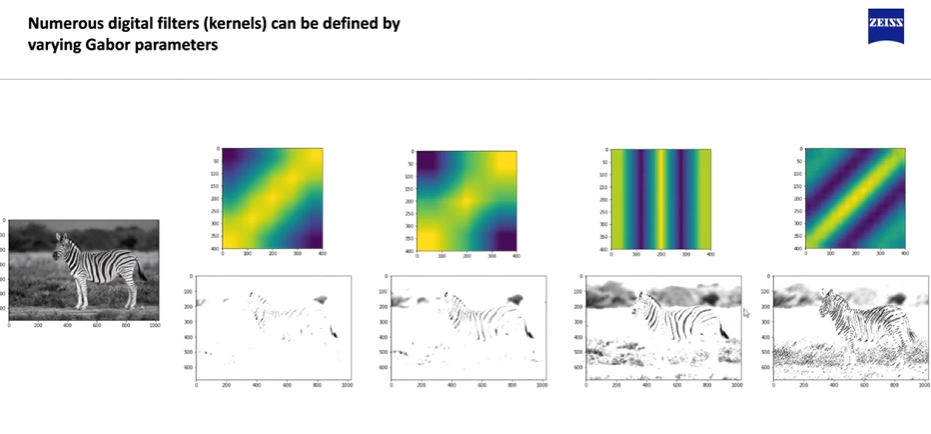
45 degree , 50d, 90 d, and so on with diff diff Parameters

In [12]:
# Gabor Filter

gaborFilt_real, gaborFilt_imag = gabor(img_arr, frequency = 0.6) 
gaborFilt = (gaborFilt_real **2 + gaborFilt_imag**2)//2

# it will rotate out and Generate results according 
#  gaborFilt_real --> from here we get real value part
# gaborFilt_imag  --> Imaginary value part


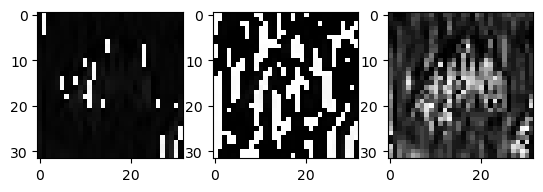

In [13]:
 # Displaying the filter Response

fig, ax = plt.subplots(1,3)
ax[0].imshow(gaborFilt_real, cmap = 'gray')
ax[1].imshow(gaborFilt_imag, cmap = 'gray')
ax[2].imshow(gaborFilt, cmap = 'gray')

# first image is real , 2nd is imaginary, 3rd one is consolidate

In [14]:
# Energy and Entropy of Gabor filter response
gabor_hist,_ = np.histogram(gaborFilt,8)
gabor_hist = np.array(gabor_hist,dtype=float)
gabor_prob = np.divide(gabor_hist,np.sum(gabor_hist))
gabor_energy = np.sum(gabor_prob**2)
gabor_entropy = -np.sum(np.multiply(gabor_prob,np.log2(gabor_prob)))
print('Gabor energy = '+str(gabor_energy))
print('Gabor entropy = '+str(gabor_entropy))

Gabor energy = 0.24701309204101562
Gabor entropy = 2.3533467655293547


#  Extracting features from all images in the dataset

In [15]:
# !pip install ipywidgets

In [16]:
# import tqdm

In [17]:
# Generating training data by extracting features from all images
import numpy as np
import sys
# USE STANDARD TQDM to avoid widget errors
from tqdm import tqdm
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.filters import gabor

label = []
featLength = 2 + 5 + 2
trainFeats = np.zeros((len(trainset), featLength))

# Small epsilon to prevent log(0) errors
eps = 1e-10

# force output to stdout to ensure it prints as text, not a widget
for tr in tqdm(range(len(trainset)), file=sys.stdout):
    img = trainset[tr][0] # One image at a time
    img_gray = img.convert('L') # Converting to grayscale
    img_arr = np.array(img_gray.getdata()).reshape(img.size[1], img.size[0])

    # --- 1. LBP ---
    # P=5, R=2. Max bins for Uniform LBP with P=5 is usually around 10-12.
    # We use bins=10 here as a safe default.
    feat_lbp = local_binary_pattern(img_arr, 5, 2, 'uniform').flatten()

    # Calculate the histogram first
    lbp_hist, _ = np.histogram(feat_lbp, bins=10, density=True)
    lbp_prob = lbp_hist # Already normalized by density=True

    lbp_energy = np.nansum(lbp_prob**2)
    # Added eps to prevent log(0)
    lbp_entropy = -np.nansum(lbp_prob * np.log2(lbp_prob + eps))

    # --- 2. GLCM ---
    gCoMat = graycomatrix(img_arr, [2], [0], 256, symmetric=True, normed=True)
    contrast = graycoprops(gCoMat, prop='contrast')
    dissimilarity = graycoprops(gCoMat, prop='dissimilarity')
    homogeneity = graycoprops(gCoMat, prop='homogeneity')
    energy = graycoprops(gCoMat, prop='energy')
    correlation = graycoprops(gCoMat, prop='correlation')
    feat_glcm = np.array([contrast[0][0], dissimilarity[0][0], homogeneity[0][0], energy[0][0], correlation[0][0]])

    # --- 3. Gabor Filter ---
    gaborFilt_real, gaborFilt_imag = gabor(img_arr, frequency=0.6)

    # Using standard magnitude formula (Sqrt of squares)
    gaborFilt = np.sqrt(gaborFilt_real**2 + gaborFilt_imag**2)

    gabor_hist, _ = np.histogram(gaborFilt, bins=8, density=True)
    gabor_prob = gabor_hist

    gabor_energy = np.nansum(gabor_prob**2)
    # Added eps to prevent log(0)
    gabor_entropy = -np.nansum(gabor_prob * np.log2(gabor_prob + eps))

    # --- 4. Concatenation ---
    concat_feat = np.concatenate(([lbp_energy, lbp_entropy], feat_glcm, [gabor_energy, gabor_entropy]), axis=0)
    trainFeats[tr, :] = concat_feat

    # Class label
    label.append(trainset[tr][1])

trainLabel = np.array(label)

100%|████████████████████████████████████████████████████████████████████████████| 50000/50000 [12:16<00:00, 67.87it/s]


In [19]:
# Generating testing data by extracting features from all images
import numpy as np
import sys
# Use standard tqdm to avoid widget errors
from tqdm import tqdm
# Note: 'graycomatrix' is the modern spelling (with an 'a')
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.filters import gabor

label = []
featLength = 2 + 5 + 2
testFeats = np.zeros((len(testset), featLength)) 

# Small epsilon to prevent log(0) errors
eps = 1e-10

# force output to stdout to ensure it prints as text, not a widget
for ts in tqdm(range(len(testset)), file=sys.stdout):
    
    img = testset[ts][0] # One image at a time
    img_gray = img.convert('L') # Converting to grayscale
    img_arr = np.array(img_gray.getdata()).reshape(img.size[1], img.size[0]) 

    # --- 1. LBP ---
    # Using bins=10 to match the Training set configuration
    feat_lbp = local_binary_pattern(img_arr, 5, 2, 'uniform').flatten()
    
    # Calculate histogram first
    lbp_hist, _ = np.histogram(feat_lbp, bins=10, density=True)
    lbp_prob = lbp_hist 
    
    lbp_energy = np.nansum(lbp_prob**2)
    # Add eps for entropy
    lbp_entropy = -np.nansum(lbp_prob * np.log2(lbp_prob + eps))

    # --- 2. GLCM ---
    # CHANGED: 'greycomatrix' -> 'graycomatrix'
    gCoMat = graycomatrix(img_arr, [2], [0], 256, symmetric=True, normed=True)
    contrast = graycoprops(gCoMat, prop='contrast')
    dissimilarity = graycoprops(gCoMat, prop='dissimilarity')
    homogeneity = graycoprops(gCoMat, prop='homogeneity')    
    energy = graycoprops(gCoMat, prop='energy')
    correlation = graycoprops(gCoMat, prop='correlation')    
    feat_glcm = np.array([contrast[0][0], dissimilarity[0][0], homogeneity[0][0], energy[0][0], correlation[0][0]])

    # --- 3. Gabor Filter ---
    gaborFilt_real, gaborFilt_imag = gabor(img_arr, frequency=0.6)
    
    # Standard magnitude calculation
    gaborFilt = np.sqrt(gaborFilt_real**2 + gaborFilt_imag**2)
    
    gabor_hist, _ = np.histogram(gaborFilt, bins=8, density=True)
    gabor_prob = gabor_hist
    
    gabor_energy = np.nansum(gabor_prob**2)
    # Add eps for entropy
    gabor_entropy = -np.nansum(gabor_prob * np.log2(gabor_prob + eps))

    # --- 4. Concatenation ---    
    concat_feat = np.concatenate(([lbp_energy, lbp_entropy], feat_glcm, [gabor_energy, gabor_entropy]), axis=0)    
    testFeats[ts, :] = concat_feat  
    
    # Class label
    label.append(testset[ts][1])

testLabel = np.array(label)

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:18<00:00, 72.28it/s]


# Feature Normalization

In [20]:
# Normalizing the train features to the range [0,1]
trMaxs = np.amax(trainFeats,axis=0) #Finding maximum along each column
trMins = np.amin(trainFeats,axis=0) #Finding maximum along each column
trMaxs_rep = np.tile(trMaxs,(50000,1)) #Repeating the maximum value along the rows
trMins_rep = np.tile(trMins,(50000,1)) #Repeating the minimum value along the rows
trainFeatsNorm = np.divide(trainFeats-trMins_rep,trMaxs_rep) #Element-wise division
# Normalizing the test features
tsMaxs_rep = np.tile(trMaxs,(10000,1)) #Repeating the maximum value along the rows
tsMins_rep = np.tile(trMins,(10000,1)) #Repeating the maximum value along the rows
testFeatsNorm = np.divide(testFeats-tsMins_rep,tsMaxs_rep) #Element-wise division

# Saving feature matrices to disk

In [21]:
# Saving normalized training data and labels
with open("trainFeats.pckl", "wb") as f:
    pickle.dump(trainFeatsNorm, f)
with open("trainLabel.pckl", "wb") as f:
    pickle.dump(trainLabel, f)
    
# Saving normalized testing data and labels
with open("testFeats.pckl", "wb") as f:
    pickle.dump(testFeatsNorm, f)
with open("testLabel.pckl", "wb") as f:
    pickle.dump(testLabel, f)
    
print('Files saved to disk!')

Files saved to disk!
